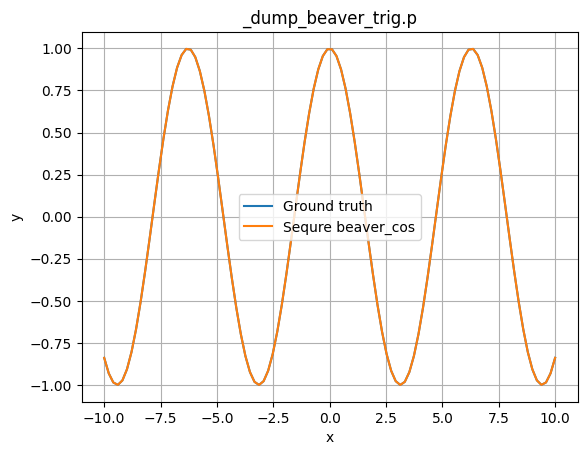

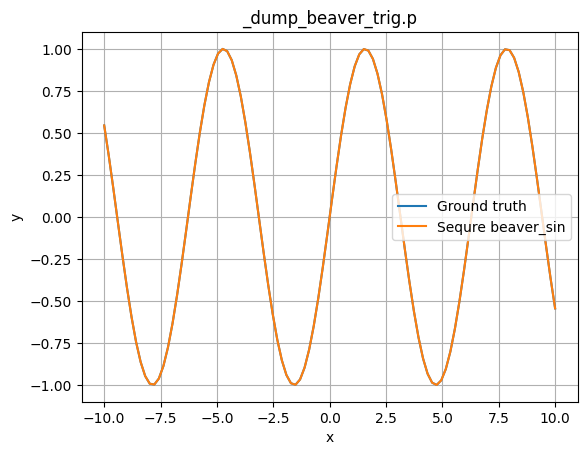

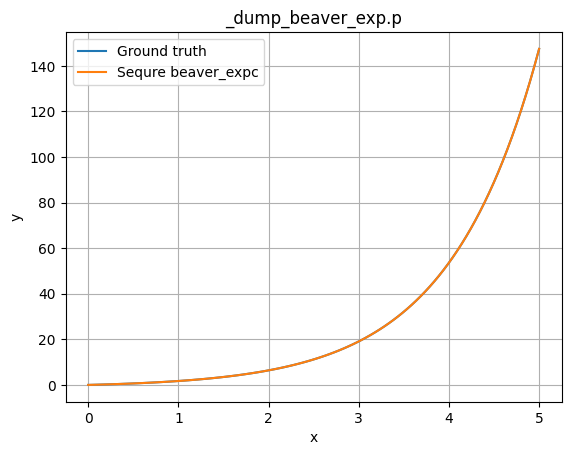

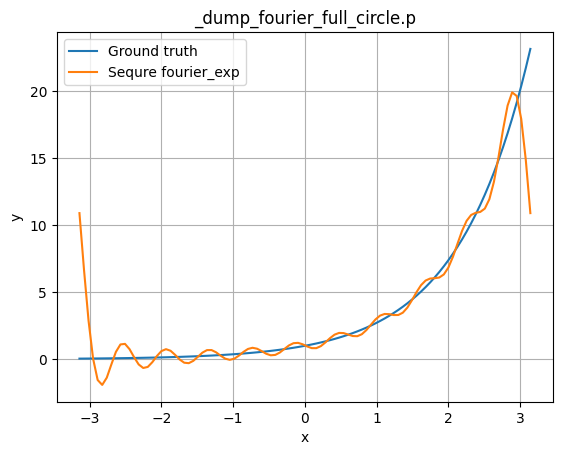

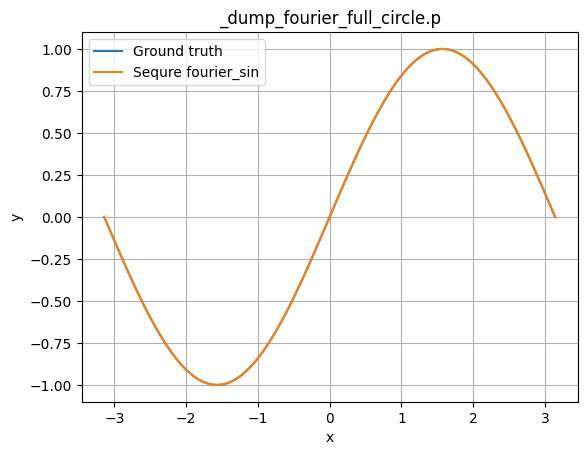

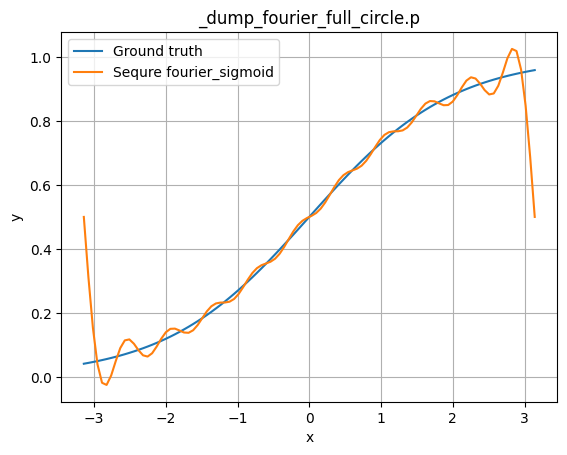

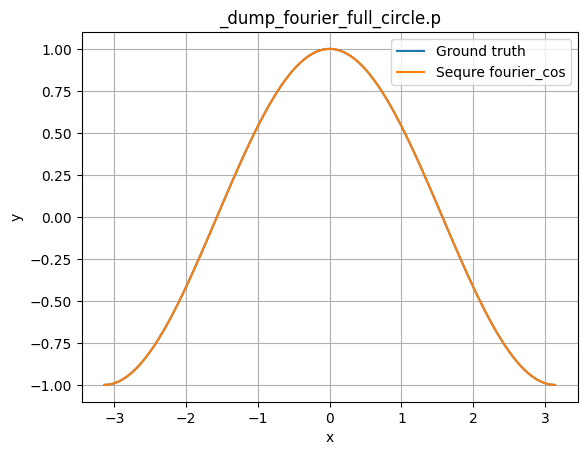

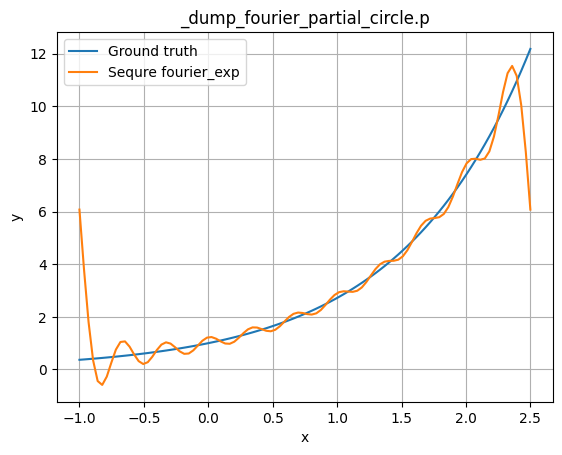

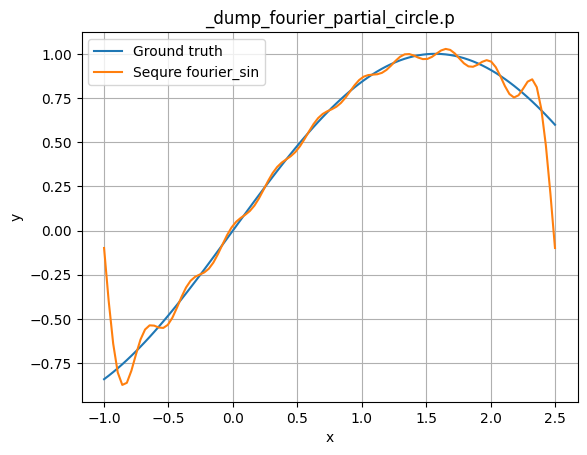

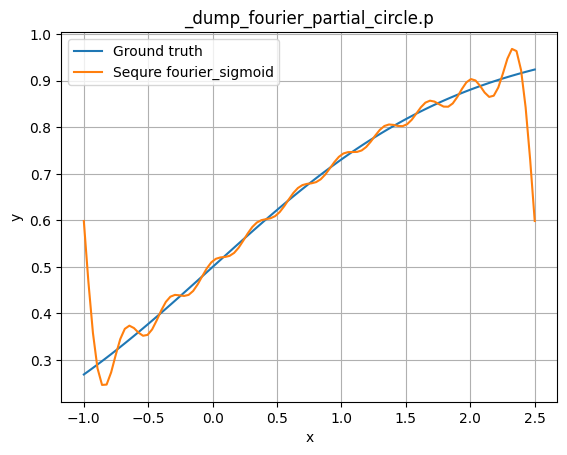

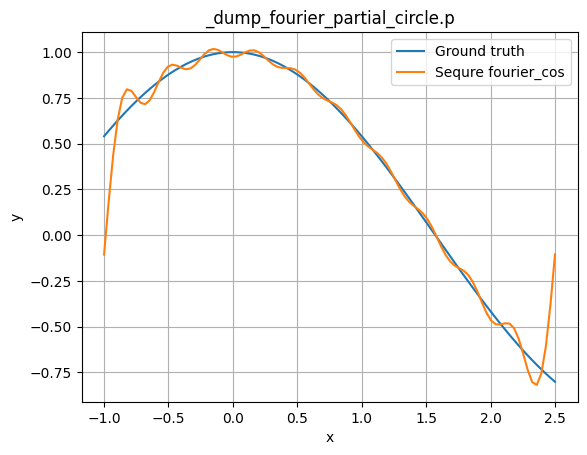

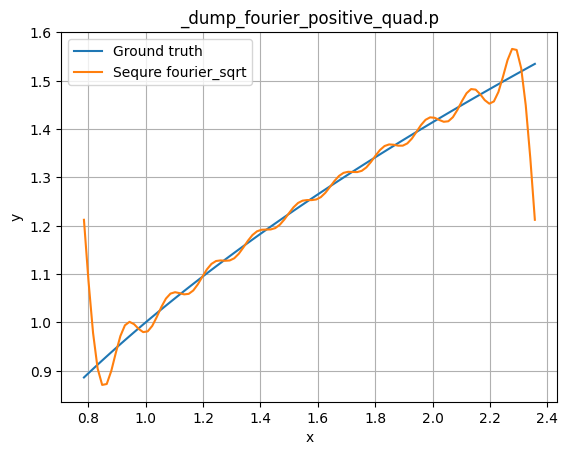

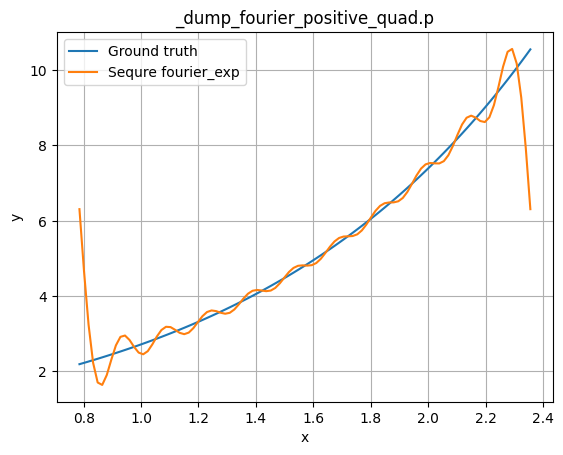

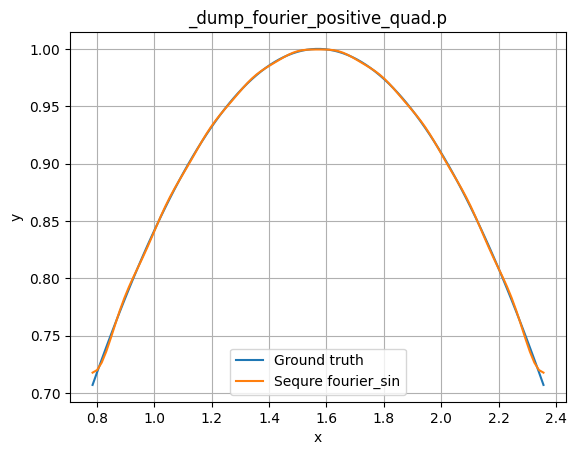

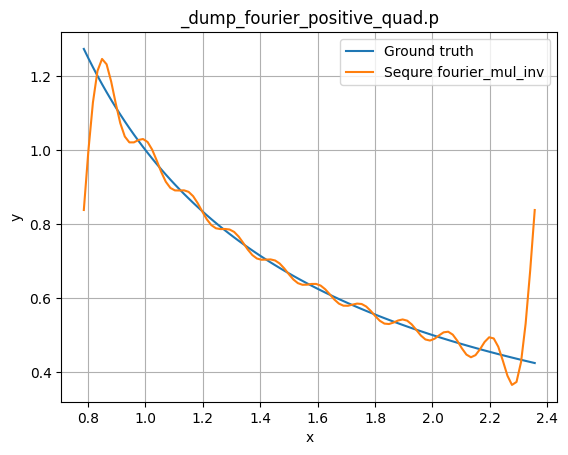

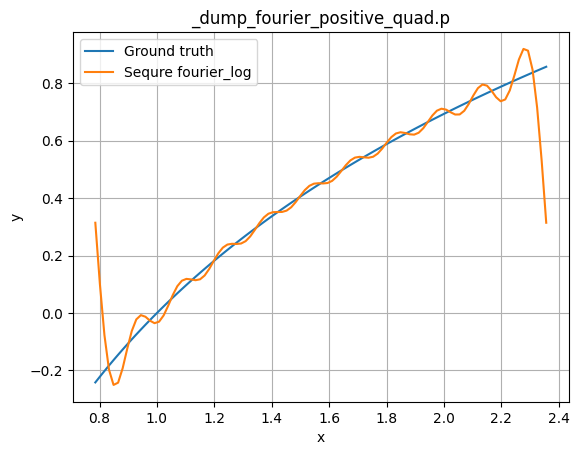

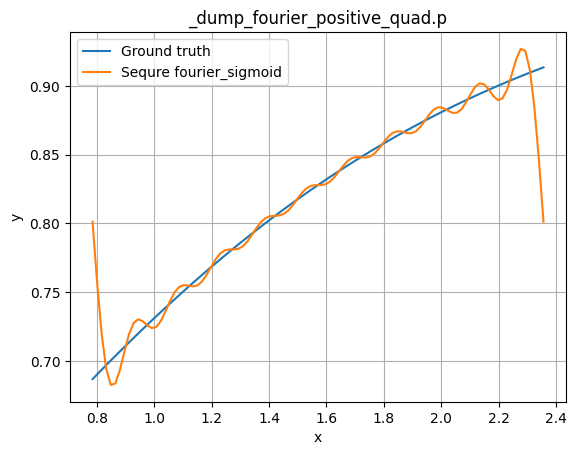

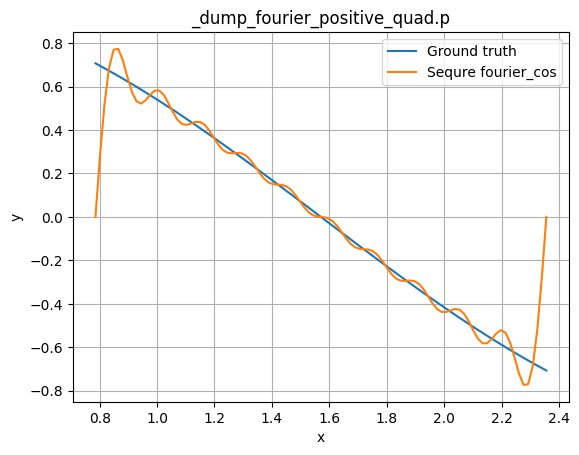

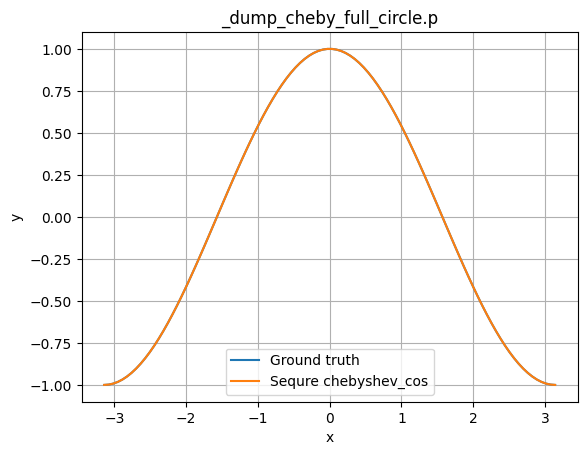

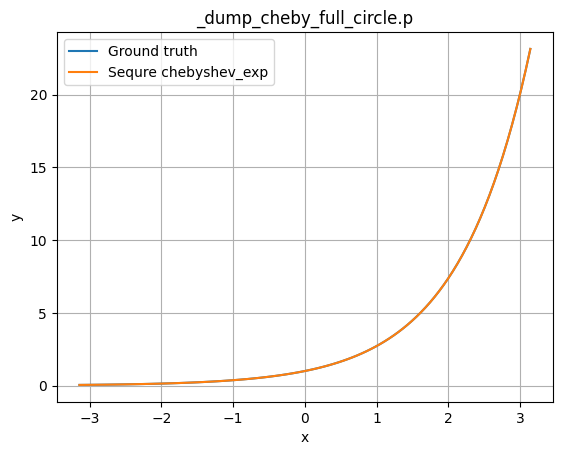

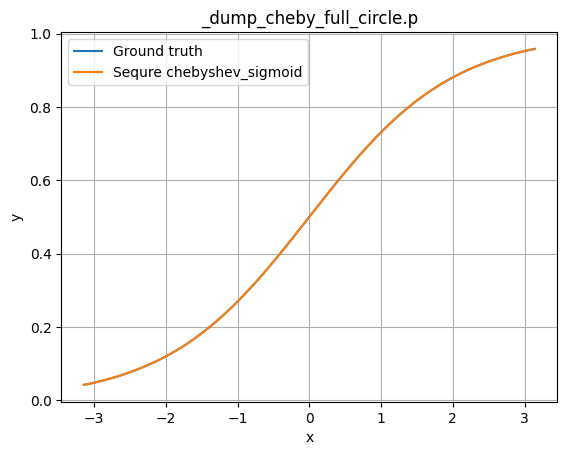

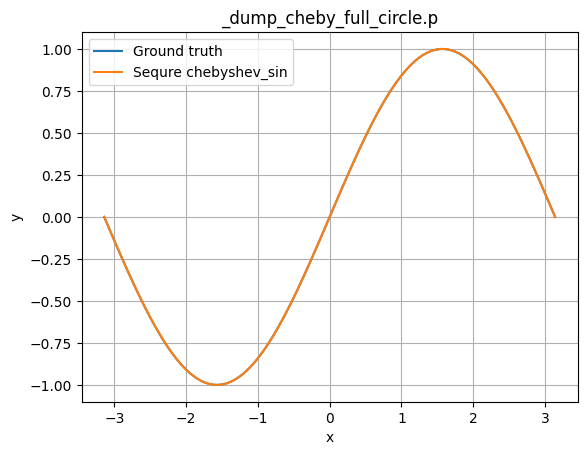

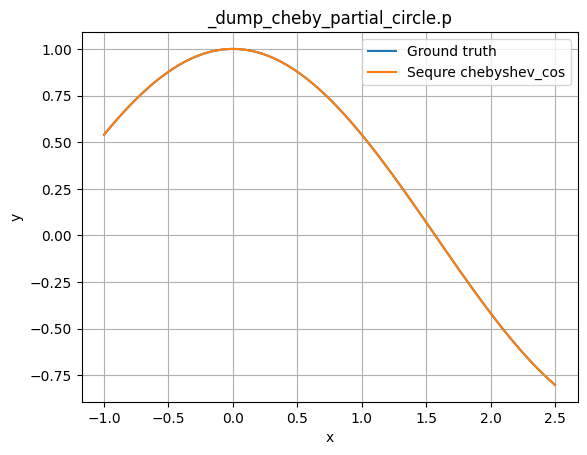

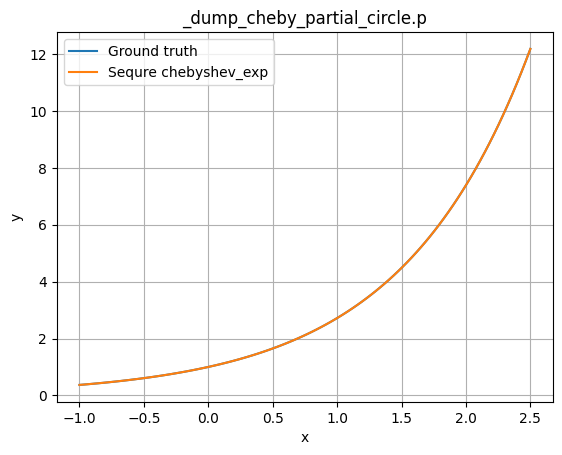

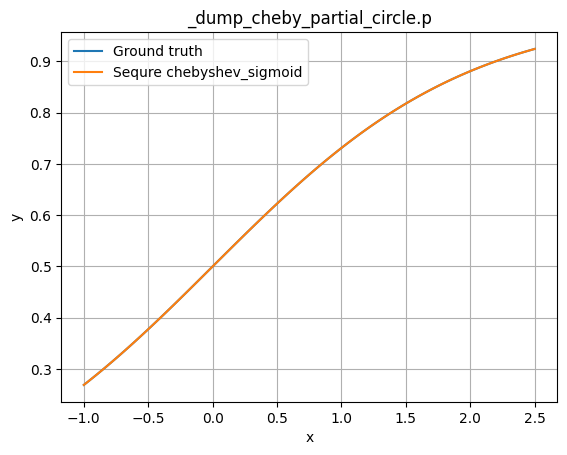

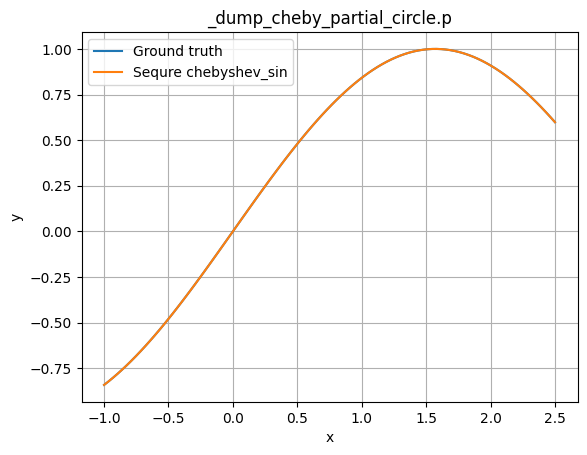

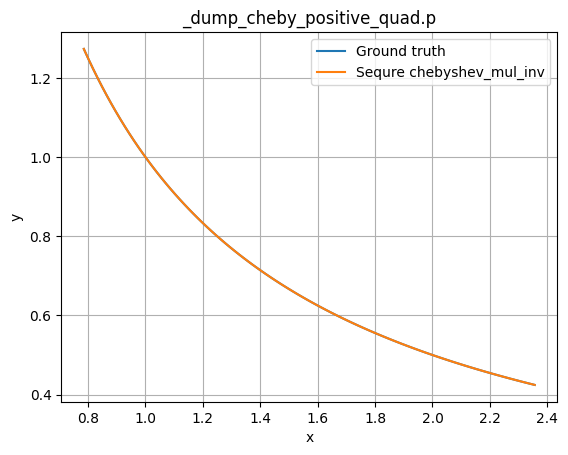

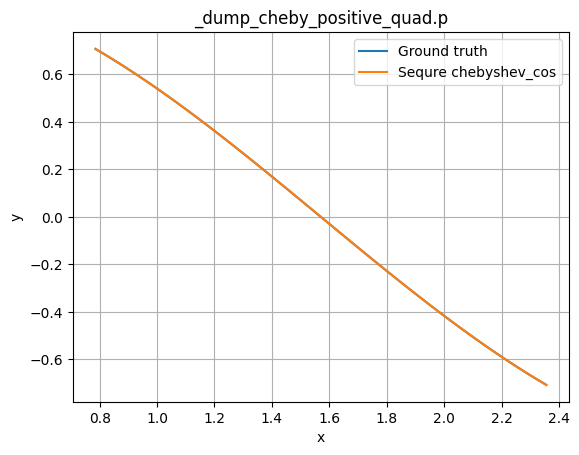

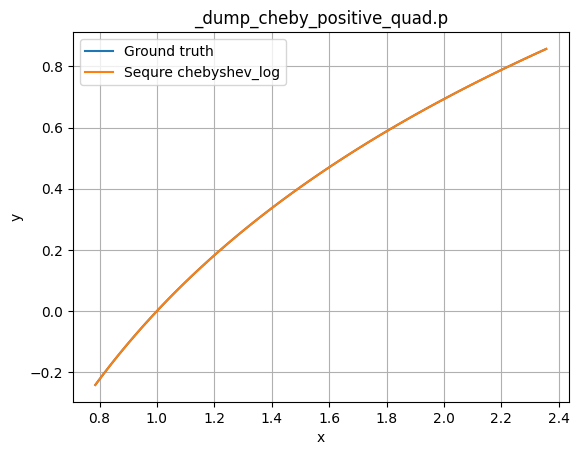

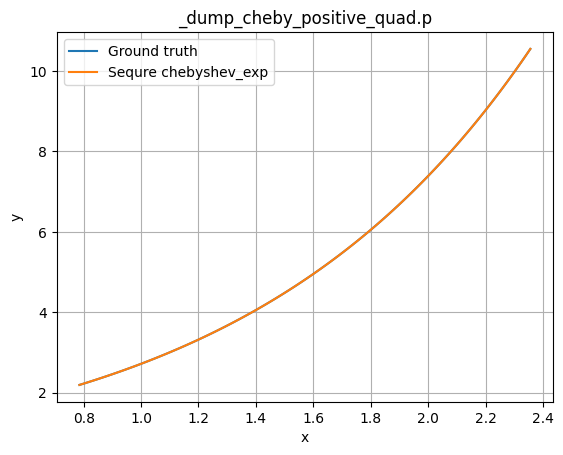

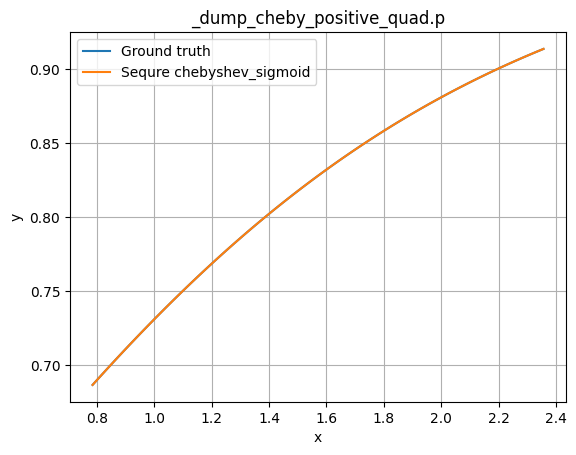

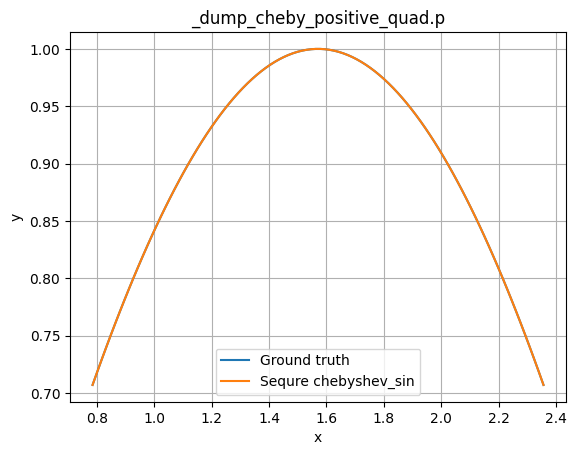

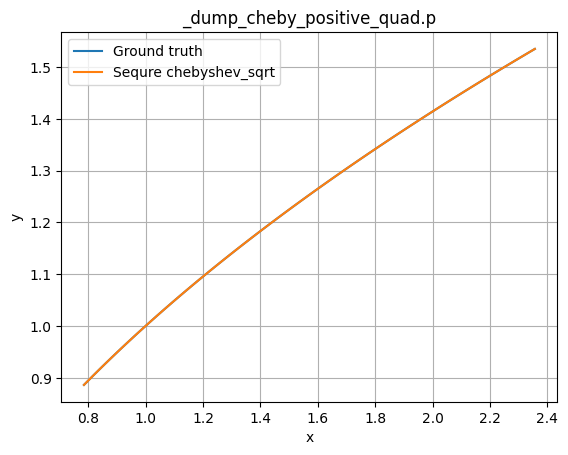

,Method,Interval,MAE,Runtime
0,beaver_cos,"(-10.0, 10.0)",5.014601e-10,0.00022
1,beaver_sin,"(-10.0, 10.0)",6.171865e-10,0.00018
2,beaver_expc,"(0.0, 5.0)",2.046542e-08,0.04826
3,fourier_exp,"(-3.14, 3.14)",8.301076e-01,0.01312
4,fourier_sin,"(-3.14, 3.14)",5.096335e-10,0.14821
5,fourier_sigmoid,"(-3.14, 3.14)",3.304574e-02,0.01302
6,fourier_cos,"(-3.14, 3.14)",5.490664e-10,0.01397
7,fourier_exp,"(-1.0, 2.5)",4.253193e-01,0.01313
8,fourier_sin,"(-1.0, 2.5)",5.198747e-02,0.01324
9,fourier_sigmoid,"(-1.0, 2.5)",2.360811e-02,0.01324


In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot(title, label, x, result, expected):
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))


# Until Codon Jupyter is fixed: Read the data from file
dump_files = [
    "_dump_beaver_trig.p",
    "_dump_beaver_exp.p",
    "_dump_fourier_full_circle.p",
    "_dump_fourier_partial_circle.p",
    "_dump_fourier_positive_quad.p",
    "_dump_cheby_full_circle.p",
    "_dump_cheby_partial_circle.p",
    "_dump_cheby_positive_quad.p"
]

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'Runtime': []}

for dump_file in dump_files:
    with open(dump_file, "rb") as f:
        data = pickle.load(f)
        x = data['x']
        interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
        for k, v in data.items():
            if k == 'x' or k.endswith("_expected") or k.endswith("_time"):
                continue
            expected = data[f"{k}_expected"]
            runtime = round(data[f"{k}_time"][0], 5)
            
            df_data['Method'].append(k)
            df_data['Interval'].append(interval)
            df_data['MAE'].append(mae(v, expected))
            df_data['Runtime'].append(runtime)
            
            plot(dump_file, k, x, v, expected)

pd.DataFrame(df_data)